In [6]:
# =============================
# Model Comparison Notebook
# =============================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:

# =============================
# CONFIG (update paths if needed)
# =============================

LOGREG_PATH = "Results/LogisticRegression/cv_summary.csv"
RF_CV_PATH = "Results/RandomForest/cv_results.pkl"  # optional if saved
RF_IMPORTANCE_PATH = "Results/RandomForest/importance.csv"
XGB_PATH = "Results/GradientBoosting/cv_summary.csv"
GAM_PATH = "Results/GAM/metrics.json"  # optional
GAM_IMPORTANCE_PATH = "Results/GAM/partial_r2.csv"
OUTPUT_DIR = "Results/ModelComparison"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [8]:

# =============================
# 1. LOAD LOGISTIC REGRESSION
# =============================

logreg = pd.read_csv(LOGREG_PATH)
logreg = logreg.rename(columns={
    "roc_auc_mean": "roc_auc",
    "average_precision_mean": "pr_auc",
    "f1_mean": "f1",
    "accuracy_mean": "accuracy",
    "recall_mean": "recall",
    "precision_mean": "precision"
})

logreg_perf = pd.DataFrame([{
    "model": "Logistic Regression",
    "roc_auc": logreg["roc_auc"].mean(),
    "pr_auc": logreg["pr_auc"].mean(),
    "f1": logreg["f1"].mean(),
    "accuracy": logreg["accuracy"].mean(),
    "recall": logreg["recall"].mean(),
    "precision": logreg["precision"].mean(),
}])

In [9]:

# =============================
# 2. LOAD XGBOOST
# =============================

xgb = pd.read_csv(XGB_PATH)
xgb_perf = pd.DataFrame([{
    "model": "XGBoost",
    "roc_auc": xgb["roc_auc_mean"].iloc[0],
    "pr_auc": xgb["average_precision_mean"].iloc[0],
    "f1": xgb["f1_mean"].iloc[0],
    "accuracy": xgb["accuracy_mean"].iloc[0],
    "recall": xgb["recall_mean"].iloc[0],
    "precision": xgb["precision_mean"].iloc[0],
}])

In [10]:
# =============================
# 3. RANDOM FOREST (UPDATED FINAL)
# =============================

import numpy as np
import pandas as pd

RF_DIR = "Results/RandomForest"

# =========================
# LOAD CV RESULTS
# =========================

rf_cv = pd.read_csv(f"{RF_DIR}/cv_results.csv", index_col=0)

# =========================
# PERFORMANCE TABLE
# =========================

rf_perf = pd.DataFrame([{
    "model": "Random Forest",
    "roc_auc": rf_cv.loc["roc_auc", "mean"],
    "pr_auc": rf_cv.loc["average_precision", "mean"],
    "f1": rf_cv.loc["f1", "mean"],
    "accuracy": rf_cv.loc["accuracy", "mean"],
    "recall": rf_cv.loc["recall", "mean"],
    "precision": rf_cv.loc["precision", "mean"],
}])

# =========================
# FEATURE IMPORTANCE (Gini)
# =========================

rf_imp = pd.read_csv(f"{RF_DIR}/feature_importance.csv")

rf_imp = rf_imp.rename(columns={"importance": "importance"})
rf_imp["model"] = "Random Forest (Gini)"
rf_imp = rf_imp[["feature", "importance", "model"]]

# =========================
# PERMUTATION IMPORTANCE (PREFERRED)
# =========================

rf_perm = pd.read_csv(f"{RF_DIR}/permutation_importance.csv")

rf_perm = rf_perm.rename(columns={"importance": "importance"})
rf_perm["model"] = "Random Forest (Perm)"
rf_perm = rf_perm[["feature", "importance", "model"]]

# Use permutation importance for downstream comparisons (recommended)
rf_imp = rf_perm

# =========================
# OPTIONAL CHECK
# =========================

print("\nRandom Forest Performance:")
print(rf_perf)

print("\nTop RF Features (Permutation Importance):")
print(rf_perm.head(10))


Random Forest Performance:
           model   roc_auc   pr_auc        f1  accuracy    recall  precision
0  Random Forest  0.612179  0.54151  0.459057  0.600732  0.441667   0.492468

Top RF Features (Permutation Importance):
                    feature  importance                 model
0             dm_noninsulin    0.085222  Random Forest (Perm)
1           days_adt_to_nht    0.060099  Random Forest (Perm)
2                       bmi    0.033005  Random Forest (Perm)
3        days_auth_to_start    0.027586  Random Forest (Perm)
4             bp_meds_prior    0.023645  Random Forest (Perm)
5       lipid_panel_checked    0.017734  Random Forest (Perm)
6                       age    0.016256  Random Forest (Perm)
7  prescribing_provider_enc    0.014778  Random Forest (Perm)
8                       dbp    0.014286  Random Forest (Perm)
9                       sbp    0.012808  Random Forest (Perm)


In [11]:

# =============================
# 4. GAM
# =============================

# expects a JSON or dict-like export
if os.path.exists(GAM_PATH):
    gam_metrics = pd.read_json(GAM_PATH, typ="series")
else:
    gam_metrics = {
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "f1": np.nan,
        "accuracy": np.nan,
        "recall": np.nan,
        "precision": np.nan,
    }

if isinstance(gam_metrics, dict):
    gam_metrics = pd.Series(gam_metrics)

gam_perf = pd.DataFrame([{
    "model": "GAM",
    "roc_auc": gam_metrics["roc_auc"],
    "pr_auc": gam_metrics["pr_auc"],
    "f1": gam_metrics["f1"],
    "accuracy": gam_metrics["accuracy"],
    "recall": gam_metrics["recall"],
    "precision": gam_metrics["precision"],
}])

In [12]:

# =============================
# 5. COMBINE PERFORMANCE
# =============================

perf_df = pd.concat([logreg_perf, xgb_perf, rf_perf, gam_perf], ignore_index=True)
perf_df.to_csv(os.path.join(OUTPUT_DIR, "model_performance_summary.csv"), index=False)

                 model   roc_auc    pr_auc        f1  accuracy    recall  \
0  Logistic Regression  0.618356  0.551058  0.515558  0.608049  0.537500   
1              XGBoost  0.643254  0.557854  0.502452  0.650000  0.455000   
2        Random Forest  0.612179  0.541510  0.459057  0.600732  0.441667   
3                  GAM  0.592500  0.515949  0.484848  0.585366  0.500000   

   precision  
0   0.499903  
1   0.566667  
2   0.492468  
3   0.470588  


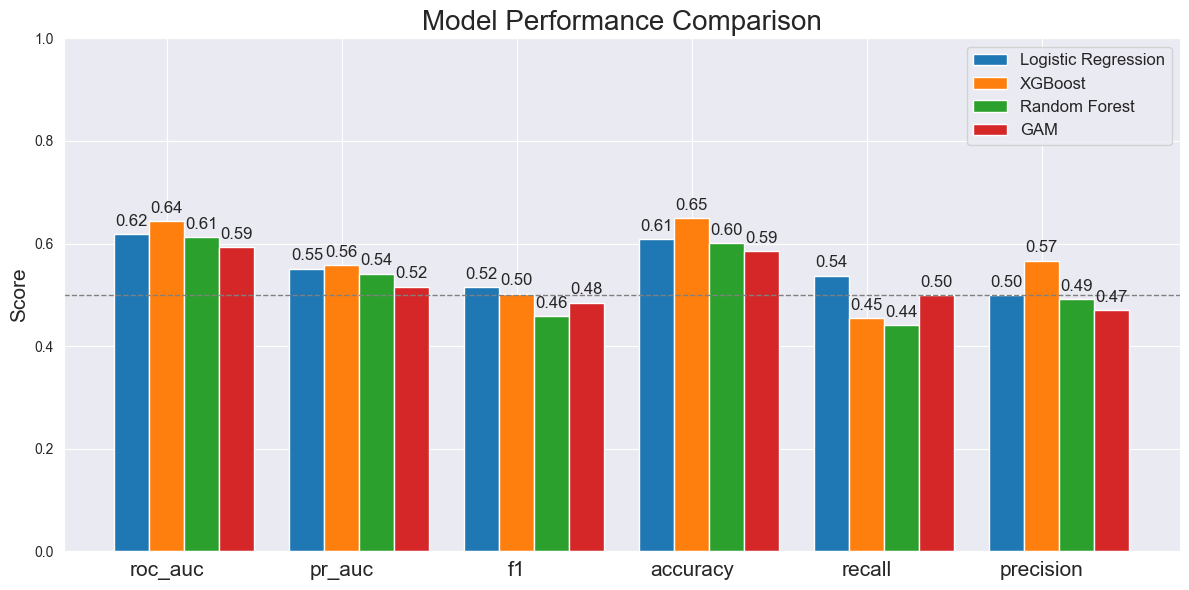

In [13]:
# =============================
# 6. PLOT PERFORMANCE COMPARISON (VERTICAL BAR VERSION)
# =============================

import numpy as np
import matplotlib.pyplot as plt
import os

metrics = ["roc_auc", "pr_auc", "f1", "accuracy", "recall", "precision"]

models = perf_df["model"].values
n_models = len(models)

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12, 6))

print(perf_df[["model"] + metrics])

for i, row in perf_df.iterrows():
    values = [row[m] for m in metrics]

    bars = plt.bar(
        x + i * width,
        values,
        width=width,
        label=row["model"]
    )

    # Add value labels
    for bar in bars:
        height_val = bar.get_height()
        if not np.isnan(height_val):
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height_val + 0.01,
                f"{height_val:.2f}",
                ha="center",
                va="bottom",
                fontsize=12
            )

# -----------------------------
# Formatting
# -----------------------------

plt.xticks(x + width, metrics, fontsize=15)
plt.ylim(0, 1)

# reference line at 0.5
plt.axhline(0.5, linestyle="--", color="gray", linewidth=1)

plt.title("Model Performance Comparison", fontsize=20)
plt.ylabel("Score", fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "model_performance_vertical.png"), dpi=300)
plt.show()

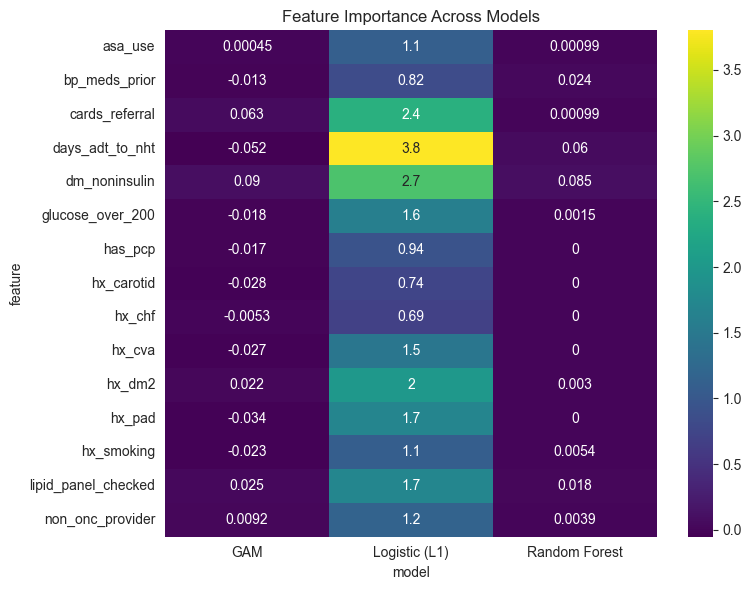

Model comparison pipeline complete.
Outputs saved to: Results/ModelComparison


In [14]:

# =============================
# 7. FEATURE IMPORTANCE UNIFICATION
# =============================

# Logistic L1 coefficients
logreg_coef = pd.read_csv("Results/LogisticRegression/coefficients.csv")
logreg_imp = logreg_coef[["feature", "L1_coef"]].copy()
logreg_imp["importance"] = logreg_imp["L1_coef"].abs()
logreg_imp["model"] = "Logistic (L1)"
logreg_imp = logreg_imp[["feature", "importance", "model"]]

# RF importance
rf_imp = rf_imp.copy()
rf_imp["model"] = "Random Forest"
rf_imp = rf_imp[["feature", "importance", "model"]]

# GAM importance
if os.path.exists(GAM_IMPORTANCE_PATH):
    gam_imp = pd.read_csv(GAM_IMPORTANCE_PATH)
    gam_imp = gam_imp.rename(columns={"partial_r2": "importance"})
    gam_imp["model"] = "GAM"
    gam_imp = gam_imp[["feature", "importance", "model"]]
else:
    gam_imp = pd.DataFrame(columns=["feature", "importance", "model"])

feature_imp = pd.concat([logreg_imp, rf_imp, gam_imp], ignore_index=True)
feature_imp.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_all.csv"), index=False)

# =============================
# 8. TOP FEATURE HEATMAP
# =============================

if len(feature_imp) > 0:
    top_features = (
        feature_imp.groupby("feature")
        ["importance"].mean()
        .sort_values(ascending=False)
        .head(15)
        .index
    )

    pivot = feature_imp[feature_imp["feature"].isin(top_features)]
    pivot = pivot.pivot_table(index="feature", columns="model", values="importance").fillna(0)

    plt.figure(figsize=(8,6))
    sns.heatmap(pivot, cmap="viridis", annot=True)
    plt.title("Feature Importance Across Models")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance_heatmap.png"), dpi=300)
    plt.show()

# =============================
# DONE
# =============================

print("Model comparison pipeline complete.")
print(f"Outputs saved to: {OUTPUT_DIR}")

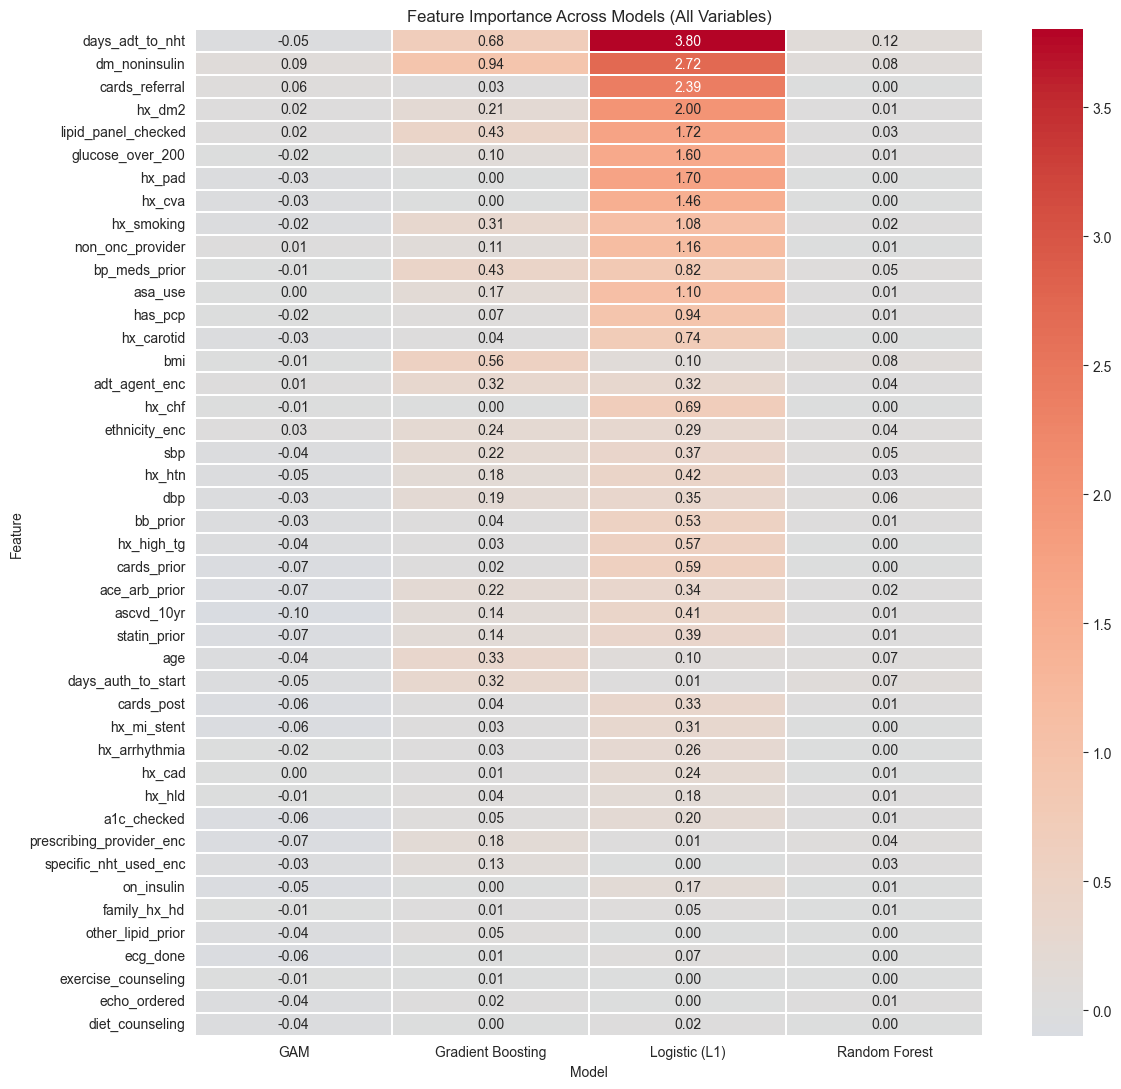

In [15]:
# =============================
# 8. FULL FEATURE HEATMAP (UPDATED WITH FILES)
# =============================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# -----------------------------
# Load external importance files
# -----------------------------

gb_imp = pd.read_csv(
    "Results/GradientBoosting/shap_feature_table.csv"
)

rf_imp = pd.read_csv(
    "Results/RandomForest/rf_coefficients_all.csv"
)

# -----------------------------
# Standardize column names
# (adjust if your files differ slightly)
# -----------------------------

gb_imp = gb_imp.rename(columns={
    gb_imp.columns[0]: "feature",
    gb_imp.columns[1]: "importance"
})
gb_imp["model"] = "Gradient Boosting"

rf_imp = rf_imp.rename(columns={
    "coefficient": "importance"
})

rf_imp["model"] = "Random Forest"

# optional: keep only gini importance if multiple types exist
rf_imp = rf_imp[rf_imp["type"] == "gini_importance"]
# -----------------------------
# Combine all feature importance tables
# -----------------------------

feature_imp_all = pd.concat([
    gb_imp,
    rf_imp,
    logreg_imp,   # keep if still in memory
    gam_imp       # keep if still in memory
], ignore_index=True)

# -----------------------------
# Clean numeric importance
# -----------------------------
feature_imp_all["importance"] = pd.to_numeric(
    feature_imp_all["importance"],
    errors="coerce"
)

# -----------------------------
# Pivot: features × models
# -----------------------------
heatmap_df = feature_imp_all.pivot_table(
    index="feature",
    columns="model",
    values="importance",
    aggfunc="mean"
).fillna(0)

# -----------------------------
# Sort by overall importance
# -----------------------------
heatmap_df = heatmap_df.loc[
    heatmap_df.mean(axis=1).sort_values(ascending=False).index
]

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(12, max(8, len(heatmap_df) * 0.25)))

sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    linecolor="white",
    annot=True,
    fmt=".2f"
)
plt.title("Feature Importance Across Models (All Variables)")
plt.xlabel("Model")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "feature_importance_heatmap_ALL.png"),
    dpi=300
)

plt.show()

In [16]:
gam_top20 = (
    gam_imp
    .copy()
    .dropna(subset=["importance"])
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\n=== GAM Top 10 Features (Partial R^2) ===")
print(gam_top20.to_string(index=False))


=== GAM Top 10 Features (Partial R^2) ===
            feature  importance
      dm_noninsulin    0.090227
     cards_referral    0.063030
      ethnicity_enc    0.034122
lipid_panel_checked    0.024606
             hx_dm2    0.021605
      adt_agent_enc    0.012707
   non_onc_provider    0.009154
             hx_cad    0.001800
            asa_use    0.000451
             hx_chf   -0.005275


In [17]:
# standardize column names if needed
gb_imp = gb_imp.rename(columns={
    gb_imp.columns[0]: "feature",
    gb_imp.columns[1]: "importance"
})

gb_top20 = (
    gb_imp
    .copy()
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\n=== Gradient Boosting Top 10 Features (SHAP) ===")
print(gb_top20.to_string(index=False))


=== Gradient Boosting Top 10 Features (SHAP) ===
            feature  importance
      dm_noninsulin    0.940560
    days_adt_to_nht    0.684085
                bmi    0.558253
      bp_meds_prior    0.427783
lipid_panel_checked    0.425126
                age    0.328410
 days_auth_to_start    0.324553
      adt_agent_enc    0.324541
         hx_smoking    0.313031
      ethnicity_enc    0.236788


In [18]:
rf_top20 = (
    rf_imp
    .copy()
    .dropna(subset=["importance"])
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\n=== Random Forest Top 10 Features (Permutation Importance) ===")
print(rf_top20.to_string(index=False))


=== Random Forest Top 10 Features (Permutation Importance) ===
                 feature  importance
         days_adt_to_nht    0.124385
                     bmi    0.084695
           dm_noninsulin    0.083078
      days_auth_to_start    0.071466
                     age    0.068093
                     dbp    0.056053
                     sbp    0.050753
           bp_meds_prior    0.048090
prescribing_provider_enc    0.044227
           ethnicity_enc    0.041987


In [19]:
gam_df = gam_imp.groupby("feature", as_index=False)["importance"].mean()
gam_df["model"] = "GAM"

gb_df = gb_imp.groupby("feature", as_index=False)["importance"].mean()
gb_df["model"] = "Gradient Boosting"

rf_df = rf_imp.groupby("feature", as_index=False)["importance"].mean()
rf_df["model"] = "Random Forest"

In [20]:
import pandas as pd

# -----------------------------
# GAM → Partial R^2
# -----------------------------
gam_df = (
    gam_imp.groupby("feature", as_index=False)["importance"]
    .mean()
    .rename(columns={"importance": "partial_r2"})
)

# -----------------------------
# Gradient Boosting → SHAP
# -----------------------------
gb_df = (
    gb_imp.copy()
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .rename(columns={"importance": "shap"})
)

# -----------------------------
# Random Forest → Permutation Importance
# -----------------------------
rf_df = (
    rf_imp.copy()
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .rename(columns={"importance": "permutation"})
)

In [21]:
all_imp = gam_df.merge(gb_df, on="feature", how="outer") \
                .merge(rf_df, on="feature", how="outer") \
                .fillna(0)

In [22]:
top_features = (
    all_imp[["partial_r2", "shap", "permutation"]]
    .abs()
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

heatmap_top10 = all_imp.loc[top_features].set_index("feature")

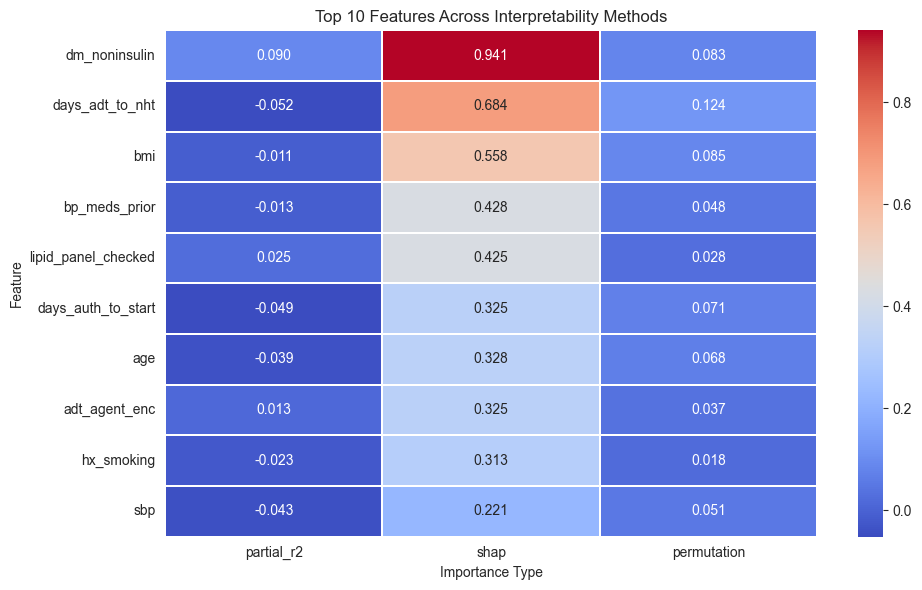

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(10, max(6, len(heatmap_top10) * 0.5)))

sns.heatmap(
    heatmap_top10,
    cmap="coolwarm",
    linewidths=0.3,
    linecolor="white",
    annot=True,
    fmt=".3f"
)

plt.title("Top 10 Features Across Interpretability Methods")
plt.xlabel("Importance Type")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "top10_feature_importance_methods.png"),
    dpi=300
)

plt.show()

In [24]:
# -----------------------------
# Print Top 10 Features Table
# -----------------------------

print("\n=== Top 10 Features Across Interpretability Methods ===")
print(
    heatmap_top10.reset_index().to_string(index=False)
)


=== Top 10 Features Across Interpretability Methods ===
            feature  partial_r2     shap  permutation
      dm_noninsulin    0.090227 0.940560     0.083078
    days_adt_to_nht   -0.051910 0.684085     0.124385
                bmi   -0.011135 0.558253     0.084695
      bp_meds_prior   -0.012973 0.427783     0.048090
lipid_panel_checked    0.024606 0.425126     0.027524
 days_auth_to_start   -0.049346 0.324553     0.071466
                age   -0.039497 0.328410     0.068093
      adt_agent_enc    0.012707 0.324541     0.036516
         hx_smoking   -0.023238 0.313031     0.018287
                sbp   -0.043395 0.221497     0.050753
